# Beyond tiles: colour and background in post

[`beyond_tiles.ipynb`](beyond_tiles.ipynb) solves free-form still-life
portraits. Solving is the expensive half — minutes at 400², thirteen minutes
at 1000², a couple of hours for a poster — and it is also the half that has
nothing to do with how the picture *looks*. The solver only ever decides
which cells are alive.

Everything after that is free. A finished pattern is a plain array of zeros
and ones, so the colours, the backdrop and the print size are all choices you
make afterwards, in milliseconds, as many times as you like. This notebook is
the second half: take one stored still life and turn it into an art piece.

**What you will do here:**

- recover a finished 400² portrait and its subject mask without running a
  solver;
- recolour it in the same **Warhol** style the tile mosaics use, now
  reproducible and guarded against pairs that wash the face out;
- put four kinds of **background** behind it — transparent, flat, an
  elementary cellular automaton, and a still-life agar;
- make the agar backdrop **alive**, so the whole canvas is one verified still
  life you can open in Golly;
- scale the winner up to print size.

No solver runs. The whole notebook is a few seconds.

## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (REPO / "src", REPO / "experiments"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Every figure below is a grid of full renders; 80 dpi keeps the committed
# notebook a sane size without losing the detail that is being compared.
plt.rcParams["figure.dpi"] = 80

## 1. The expensive part, already done

Two things come out of a solve and both are cheap to recover.

The **pattern** ships in the repository as a bit-packed array — the 400²
portrait from the champion pipeline, 177 seconds of CP-SAT compressed to
about 6 kB on disk.

The **mask** says which cells belong to the subject and which are backdrop.
The solver needs it (background cells are forced dead), and so does anything
that wants to paint behind the subject. It is not stored, because it does not
need to be: it is a deterministic function of the source image, which *is* in
the repository and is already alpha-cut. Recomputing it is one call, pure
PIL, no background-removal model, no solver.

One convention to keep straight, because the two halves of this repository
disagree. The solver's `free_mask` is `True` **on the subject**. The renderer
wants a mask that is `True` **on the background**. So every call below passes
`~free`.

pattern (400, 400), 26,960 live cells (16.9% density)
subject 120,491 cells, background 39,509 cells
live cells sitting in the background: 0


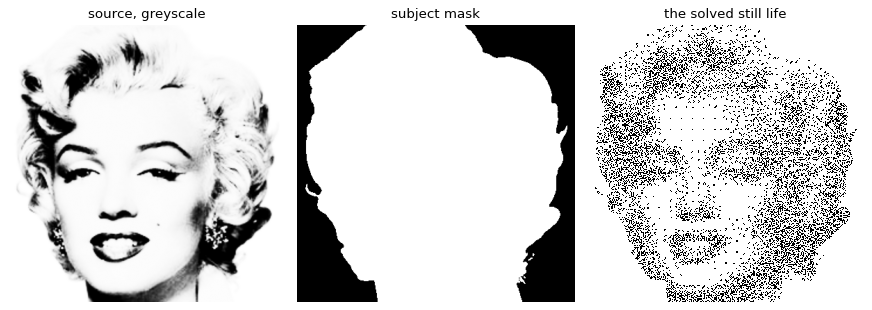

In [2]:
from beyond_tiles.artifacts import ASSETS, load_pattern_asset
from beyond_tiles.targets import grey_and_mask_from_image

SIZE = 400
pattern = load_pattern_asset(ASSETS / "marilyn_400_pipeline.npz")
grey, free = grey_and_mask_from_image(REPO / "input/images/marilyn.png", SIZE)
background = ~free   # the renderer's convention

print(f"pattern {pattern.shape}, {pattern.sum():,} live cells "
      f"({pattern.mean():.1%} density)")
print(f"subject {free.sum():,} cells, background {background.sum():,} cells")
print(f"live cells sitting in the background: {pattern[background].sum()}")

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
axes[0].imshow(grey, cmap="gray")
axes[0].set_title("source, greyscale")
axes[1].imshow(free, cmap="gray")
axes[1].set_title("subject mask")
axes[2].imshow(1 - pattern, cmap="gray", interpolation="nearest")
axes[2].set_title("the solved still life")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

That last printed number is the one that matters: **zero** live cells outside
the subject. The mask lines up with the pattern the solver was given, so the
whole background region is empty canvas — free real estate.

## 2. Colour

`ColorScheme` is the same object the tile mosaics use, and `compose` is happy
with any of its presets. Each of these renders in about ten milliseconds.

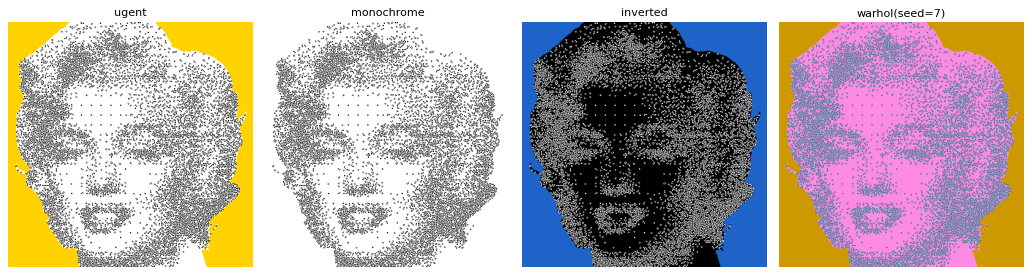

In [3]:
from gol_mosaics import ColorScheme, compose

schemes = [
    ("ugent", ColorScheme.ugent()),
    ("monochrome", ColorScheme.monochrome()),
    ("inverted", ColorScheme.inverted()),
    ("warhol(seed=7)", ColorScheme.warhol(seed=7)),
]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, (name, scheme) in zip(axes, schemes):
    ax.imshow(np.asarray(compose(pattern, background, scheme, style="flat")))
    ax.set_title(name, fontsize=10)
    ax.axis("off")
plt.tight_layout()

### The Warhol grid

`ColorScheme.warhol()` draws two colours from a pop-art palette. Two things
changed for this notebook to be usable.

**It takes a seed.** It used to spin up its own random generator, which meant
no seed anywhere in the codebase could reproduce a scheme — every re-run of a
grid like the one below gave different colours, so you could never point at
the one you liked.

**It guards contrast.** A free-form still life carries tone as *local
live-cell density*, not as pixel brightness, so two colours that are close in
brightness do not merely recolour the portrait, they erase it. The palette
contains real offenders — `deep_gold #cc9a00` on `pastel_pink #ff9ecb` are
0.16 apart on a 0-to-1 luma scale. `warhol()` now redraws any pair closer
than `min_luma_gap` (0.35 by default), for the tile mosaics too.

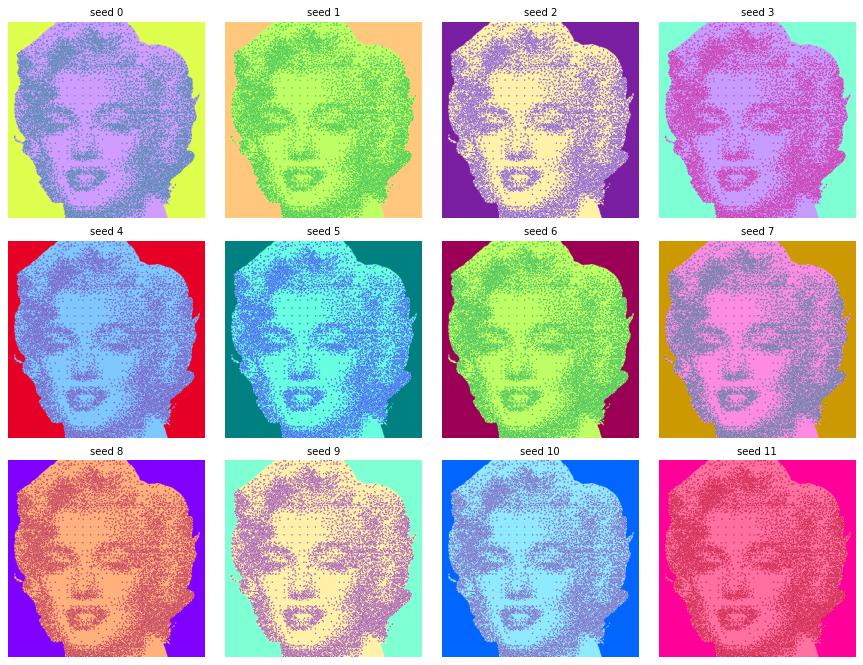

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(11, 8.4))
for seed, ax in enumerate(axes.ravel()):
    ax.imshow(np.asarray(
        compose(pattern, background, ColorScheme.warhol(seed=seed), style="flat")
    ))
    ax.set_title(f"seed {seed}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

Re-run that cell and you get the same twelve panels. Pick a seed and it stays
picked.

## 3. Backgrounds

`compose` offers four backdrop styles, all painted into the mask's background
region and none of them touching the subject:

| style | what it draws | alive? |
|---|---|---|
| `none` | nothing — transparent, for dropping onto another canvas | no |
| `flat` | a solid fill in the scheme's field colour | no |
| `eca` | an elementary cellular automaton, as in the tile mosaics | no |
| `agar` | a lattice of still-life blocks | **yes** |

The first three are paint. They are never part of a Golly export and the
verified still life underneath is untouched. Only `agar` puts down real Game
of Life cells — §4 makes that formal.

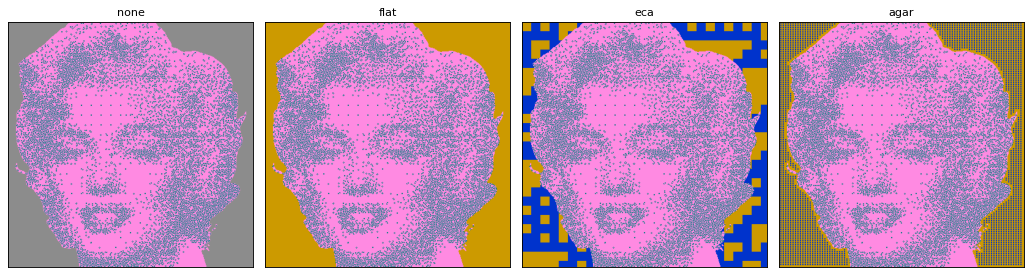

In [5]:
scheme = ColorScheme.warhol(seed=7)
styles = ["none", "flat", "eca", "agar"]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, style in zip(axes, styles):
    ax.imshow(np.asarray(
        compose(pattern, background, scheme, style=style, rule=110)
    ))
    ax.set_facecolor("0.55")          # so `none` reads as transparent
    ax.set_title(style, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()

### Choosing a texture

The ECA backdrop takes any of Wolfram's 256 rules and a cell size in pixels;
the mosaic pipeline's favourites are collected in `ECABackground.COMPLEX_RULES`
and `CHAOTIC_RULES`. The agar backdrop takes a lattice pitch, which sets how
dense the blocks sit.

complex rules: [54, 147, 110, 124, 137, 193]
chaotic rules: [30, 45, 106, 150]


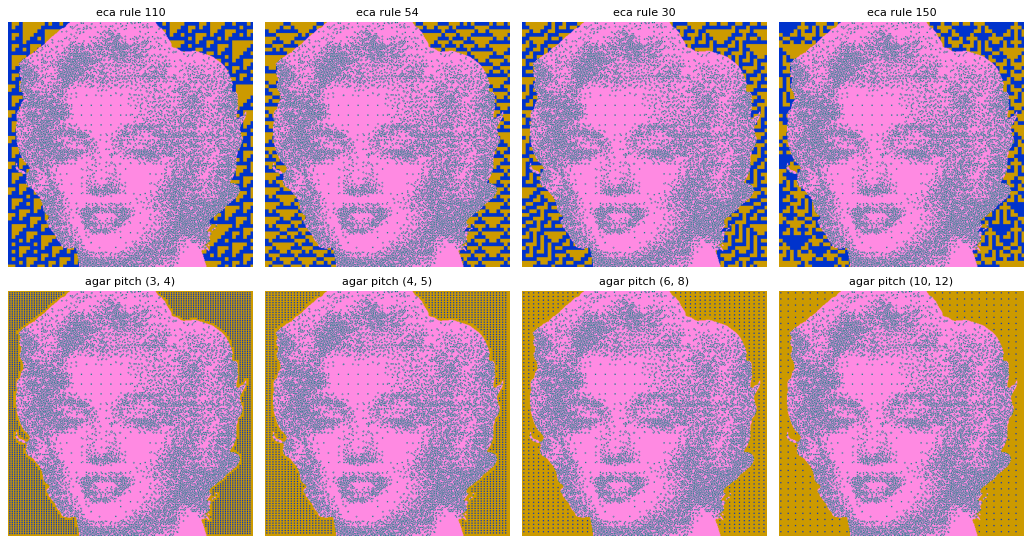

In [6]:
from gol_mosaics import ECABackground

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, rule in zip(axes[0], [110, 54, 30, 150]):
    ax.imshow(np.asarray(compose(pattern, background, scheme,
                                 style="eca", rule=rule, supersample=6)))
    ax.set_title(f"eca rule {rule}", fontsize=10)
for ax, pitch in zip(axes[1], [(3, 4), (4, 5), (6, 8), (10, 12)]):
    ax.imshow(np.asarray(compose(pattern, background, scheme,
                                 style="agar", pitch=pitch)))
    ax.set_title(f"agar pitch {pitch}", fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

print("complex rules:", ECABackground.COMPLEX_RULES)
print("chaotic rules:", ECABackground.CHAOTIC_RULES)

## 4. A background that is alive

The agar backdrop is not decoration. Merge it into the pattern and the whole
canvas — portrait and backdrop together — is a single Game of Life still
life you can open in Golly and step forever.

Two facts make that work, and neither needed new mathematics.

**The agar is stable for any subset of its blocks.** It is the construction
the beyond-tiles warm-start seeds already use: 2×2 blocks on a lattice with
period 3 in rows and 4 in columns. That asymmetric pitch is the whole trick —
with it, no dead cell can ever see exactly three live neighbours no matter
which sites are filled, so dropping blocks wherever the mask says "subject"
is safe by construction. No repair pass, no seams. (A square period-3 lattice
does *not* have this property, which is why the pitch is 3×4.)

**The two populations never meet.** A block is kept only where the mask is
background for two cells in every direction. That puts every agar cell at
Chebyshev distance 3 or more from every subject cell, so no dead cell's 3×3
neighbourhood can contain one of each. Neither population sees the other,
both keep the neighbour counts they were verified with, and the union is
stable.

`life_safe_pattern` does the merge and refuses if the pattern has live cells
in the background region, where the guarantee would not hold.

subject 26,960 + agar 6,588 = 33,548 live cells
verify: {'bounded': True, 'toroidal': True}
exported output/golly/beyond_tiles_art.cells (157 kB)


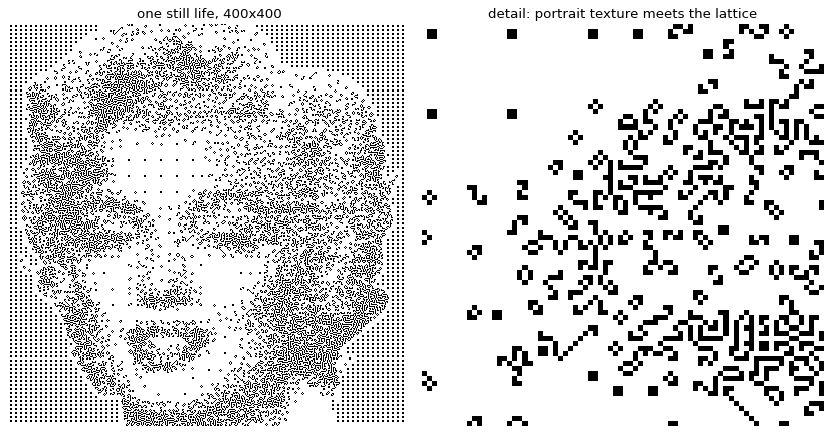

In [7]:
from gol_mosaics import life_safe_pattern
from gol_mosaics.export import GollyExporter
from beyond_tiles.still_image import verify_still_life

whole = life_safe_pattern(pattern, background, pitch=(4, 5))
print(f"subject {pattern.sum():,} + agar {whole.sum() - pattern.sum():,} "
      f"= {whole.sum():,} live cells")
print("verify:", verify_still_life(whole))

out = REPO / "output/golly/beyond_tiles_art.cells"
GollyExporter.export_to_cells(whole, str(out))
print("exported", out.relative_to(REPO), f"({out.stat().st_size / 1024:.0f} kB)")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.4))
axes[0].imshow(1 - whole, cmap="gray", interpolation="nearest")
axes[0].set_title("one still life, 400x400")
axes[1].imshow(1 - whole[150:230, 150:230], cmap="gray", interpolation="nearest")
axes[1].set_title("detail: portrait texture meets the lattice")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

`{'bounded': True, 'toroidal': True}` — stable both as a finite pattern and
wrapped on a torus. The detail panel is the interesting part: on the left the
solver's texture, in which 92% of 6×6 blocks occur exactly once, and on the
right a perfectly regular lattice. Same rule set, same picture, and the seam
between them is nothing but empty space.

## 5. A background of tiles

The agar is a lattice this repository borrowed. There is a better one sitting
right here: the **pond tiles** the rest of the project is built from — the
still lifes enumerated by SAT, level by level, that the mosaic pipeline packs
into portraits. Putting a free-form subject on a field of them is the pairing
this notebook was heading for: the two halves of the repository, from opposite
ends of the same problem, in one image.

`mosaic_background` builds that field. Nothing is re-solved; it is the same
post-hoc trick as everything above.

**The lattice does not have to fit the canvas.** That is the thing worth being
clear about, because it sounds like it should be a problem. `tile_scheme.assemble`
already accepts an index grid with `-1` marking a hole, and a hole-punched
mosaic is stable because *every subset of the frame lattice is a still life*.
So sites that do not fit simply go unused. The grid needs no common factor with
8, with 400, or with the tile size.

**The safety rule is about boxes, not cells.** Tiles are `6 × level` cells wide
and adjacent tiles *overlap* — the square lattice shares a border pond band,
the diamond lattice shares corner ponds. So the clearance test cannot look at
individual live cells the way the agar's does; it has to reject a whole
lattice site whose entire box comes within two cells of the subject. Everything
written then lies inside a box that is clear, every mosaic cell is at Chebyshev
distance 3 or more from every subject cell, and the same argument as the agar
applies unchanged.

**The price is a halo.** Reject a whole box and you lose up to `6 × level`
cells of background around the figure. That margin is deliberate here: it reads
as a matte, and it is what keeps a busy lattice from crowding the portrait.

level 2: tile 12 cells,  7,760 background cells, halo up to 12 cells
level 3: tile 18 cells,  5,488 background cells, halo up to 18 cells
level 4: tile 24 cells,  3,876 background cells, halo up to 24 cells
level 5: tile 30 cells,  2,096 background cells, halo up to 30 cells


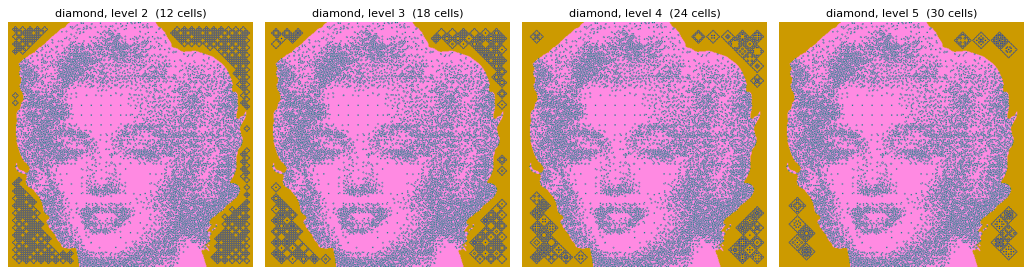

In [8]:
from gol_mosaics import mosaic_background

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, level in zip(axes, [2, 3, 4, 5]):
    ax.imshow(np.asarray(compose(pattern, background, scheme,
                                 style="mosaic", level=level, seed=1)))
    ax.set_title(f"diamond, level {level}  ({6 * level} cells)", fontsize=10)
    ax.axis("off")
plt.tight_layout()

for level in (2, 3, 4, 5):
    field = mosaic_background(background, level=level, seed=1)
    print(f"level {level}: tile {6 * level:2d} cells, "
          f"{field.sum():>6,} background cells, halo up to {6 * level} cells")

Level sets both how big a tile reads against the figure and how intricate it
is allowed to be. But look at the counts, because they run the wrong way:
level 2 lays down 7,760 background cells and level 5 only 2,096. Bigger tiles
need a bigger box to be clear, and a bigger box is rejected more often — the
halo eats the field.

This crop of Marilyn is the hard case for that, and it is worth being blunt
about it. She fills the frame; only about a quarter of the canvas is
background at all, and at level 5 the halo claims most of what is left, so the
lattice survives only in the corners. On a poster with real background around
the subject (section 7) level 5 and 6 come into their own. Here, level 2 or 3
is what actually reads as a field.

Two lattices are available. The **diamond** is the historical geometry the
paper is about, its ponds chained corner to corner on a 45° basis. The
**square** is the axis-aligned family from `tile_scheme`, tiles sharing a
border band of separated ponds. Same guarantee, different rhythm.

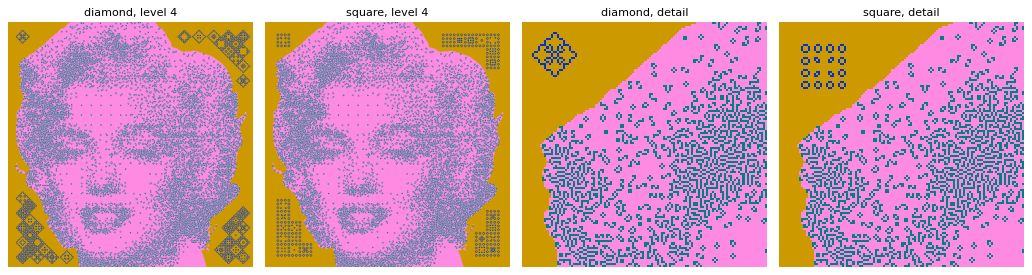

In [9]:
CROP = slice(8, 128)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, shape in zip(axes[:2], ["diamond", "square"]):
    ax.imshow(np.asarray(compose(pattern, background, scheme,
                                 style="mosaic", level=4, shape=shape, seed=1)))
    ax.set_title(f"{shape}, level 4", fontsize=10)
for ax, shape in zip(axes[2:], ["diamond", "square"]):
    art = np.asarray(compose(pattern, background, scheme,
                             style="mosaic", level=4, shape=shape, seed=1))
    ax.imshow(art[CROP, CROP], interpolation="nearest")
    ax.set_title(f"{shape}, detail", fontsize=10)
for ax in axes:
    ax.axis("off")
plt.tight_layout()

### Which tiles, and where

Two knobs choose the tiles themselves. `density` takes a band and the field is
drawn at random from the tiles inside it — a sparse band gives a quiet
backdrop, a dense one a loud lattice. `tone` grades that band across the
canvas instead of sampling it uniformly.

One trap worth naming: `PatternLibrary.densities` is min-max normalised *per
level*, so `(0.3, 0.7)` is a relative band, not an absolute fill. `density_band`
reports both, which is why the print below shows two scales.

level 5 diamond: normalised band -> tiles, absolute fill
    (0.0, 0.2) ->    66 tiles, fill 0.080-0.111,  1,264 cells laid down
    (0.3, 0.5) ->   750 tiles, fill 0.129-0.156,  1,736 cells laid down
    (0.6, 0.8) ->   812 tiles, fill 0.173-0.204,  2,316 cells laid down
   (0.85, 1.0) ->   406 tiles, fill 0.213-0.236,  2,732 cells laid down


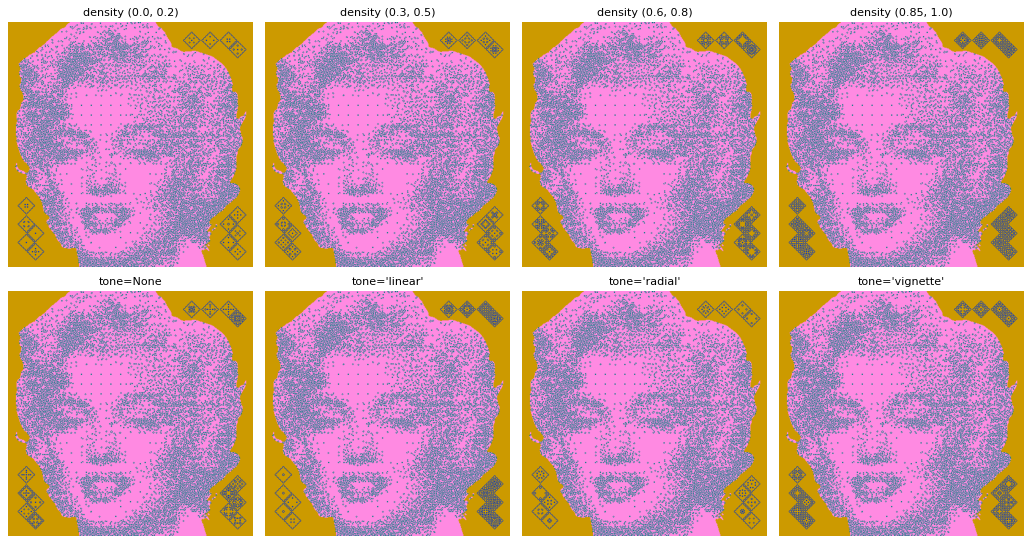

In [10]:
from gol_mosaics import density_band

LEVEL, SHAPE = 5, "diamond"
BANDS = [(0.0, 0.2), (0.3, 0.5), (0.6, 0.8), (0.85, 1.0)]
TONES = [None, "linear", "radial", "vignette"]

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, band in zip(axes[0], BANDS):
    ax.imshow(np.asarray(compose(pattern, background, scheme, style="mosaic",
                                 level=LEVEL, shape=SHAPE, density=band, seed=4)))
    ax.set_title(f"density {band}", fontsize=10)
for ax, tone in zip(axes[1], TONES):
    ax.imshow(np.asarray(compose(pattern, background, scheme, style="mosaic",
                                 level=LEVEL, shape=SHAPE, density=(0.0, 1.0),
                                 tone=tone, seed=4)))
    ax.set_title(f"tone={tone!r}", fontsize=10)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()

print(f"level {LEVEL} {SHAPE}: normalised band -> tiles, absolute fill")
for band in BANDS:
    indices, (low, high) = density_band(LEVEL, SHAPE, band)
    field = mosaic_background(background, level=LEVEL, shape=SHAPE,
                              density=band, seed=4)
    print(f"  {str(band):>12} -> {len(indices):>5,} tiles, "
          f"fill {low:.3f}-{high:.3f}, {field.sum():>6,} cells laid down")

### And it is alive too

Everything the agar earned in section 4 carries over, because the argument is
the same one. `life_safe_pattern` takes the field and merges it in — and
**checks it rather than trusting it**: any cell within two of the subject, or
within two of the border, and it refuses. That check is the only thing standing
between a caller and a false claim of stability, so it is not optional.

The result is one Game of Life still life: a CP-SAT portrait sitting in a field
of SAT-enumerated pond tiles, the whole canvas stable, exportable to Golly as a
single object.

subject 26,960 + tiles 8,896 = 35,856 live cells
verify: {'bounded': True, 'toroidal': True}
exported output/golly/beyond_tiles_mosaic.cells (157 kB)


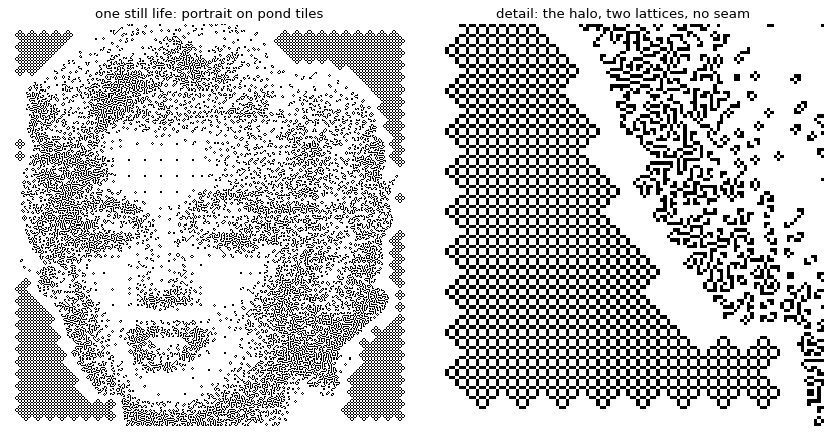

In [11]:
tiles = mosaic_background(background, level=2, shape="diamond",
                          density=(0.6, 1.0), seed=11)
whole_tiles = life_safe_pattern(pattern, background, field=tiles)

print(f"subject {pattern.sum():,} + tiles {tiles.sum():,} "
      f"= {whole_tiles.sum():,} live cells")
print("verify:", verify_still_life(whole_tiles))

out = REPO / "output/golly/beyond_tiles_mosaic.cells"
GollyExporter.export_to_cells(whole_tiles, str(out))
print("exported", out.relative_to(REPO), f"({out.stat().st_size / 1024:.0f} kB)")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.4))
axes[0].imshow(1 - whole_tiles, cmap="gray", interpolation="nearest")
axes[0].set_title("one still life: portrait on pond tiles")
axes[1].imshow(1 - whole_tiles[280:400, 0:120], cmap="gray",
               interpolation="nearest")
axes[1].set_title("detail: the halo, two lattices, no seam")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

The detail panel shows what the halo actually buys. The tiles stop a clean
tile-width short of the portrait, and the empty band between them is the whole
proof: neither population is in the other's neighbourhood, so neither can
disturb it.

It also costs something, and the next section is about paying less for it.

### Filling the gap

The halo is not one width — it is whatever the lattice happens to allow. A
tile is seated only where its whole `6 * level` box fits with clearance, so
next to a ragged silhouette the nearest tile can be a long way off, and the
distance swings from place to place. That unevenness is what reads as untidy,
not the width itself.

Measure it as the Chebyshev distance from each silhouette cell to the nearest
background cell, and compare the plain mosaic with `filled_background`, which
runs the same generator again at smaller levels and then scatters loose
elementary still lifes into what is left.

In [12]:
from scipy.ndimage import binary_dilation, distance_transform_cdt

from gol_mosaics import filled_background, scatter_background

silhouette = free & binary_dilation(background, np.ones((3, 3), bool))


def halo(field):
    """Chebyshev distance from each silhouette cell to the nearest field cell."""
    empty = np.asarray(field) == 0
    return distance_transform_cdt(empty, metric="chessboard")[silhouette]


print(f"{'level':>5}   {'plain mean':>10} {'max':>4}   {'filled mean':>11} {'max':>4}"
      f"   background cells")
for level in (2, 4, 5):
    plain = mosaic_background(background, level=level, seed=1)
    filled = filled_background(background, level=level, seed=1)
    before, after = halo(plain), halo(filled)
    print(f"{level:>5}   {before.mean():>10.1f} {before.max():>4}"
          f"   {after.mean():>11.1f} {after.max():>4}"
          f"   {plain.sum():>6,} -> {(filled != 0).sum():>6,}")

level   plain mean  max   filled mean  max   background cells


    2         12.4   58           4.9   12    7,760 ->  9,091
    4         33.7  121           5.2   14    3,876 ->  7,493


    5         69.5  240           5.0   12    2,096 ->  6,799


The worst case is what moves. It cannot reach zero: `gap + 1` is the clearance
that makes the union a still life, so three cells is the floor, and every
number above is honest distance from it.

The trick behind it is one line. Hand each pass `background & ~placed` and
`mosaic_background`'s existing box rule does the rest: the box plus its margin
must be clear of every cell already down, which is exactly the separation the
still-life argument needs. Nothing about the theorem changes, and nothing is
re-solved.

Watch what each layer actually contributes.

In [13]:
placed = np.zeros(background.shape, dtype=bool)
print("layer       added   running total")
for level in (4, 3, 2, 1):
    layer = mosaic_background(background & ~placed, level=level, seed=level)
    placed |= layer.astype(bool)
    print(f"level {level}   {layer.sum():>7,}   {placed.sum():>7,}")

loose = scatter_background(background, occupied=placed, band=18, seed=9)
print(f"scatter   {loose.sum():>7,}   {(placed | loose.astype(bool)).sum():>7,}")

layer       added   running total
level 4     3,572     3,572
level 3       260     3,832
level 2       272     4,104


level 1     2,568     6,672


scatter       543     7,215


Most of the cascade is a near no-op, and saying so is the honest result: once
level 4 is down, its cells are spread across the whole field and there is
almost nowhere a level-3 box still fits. The work is done at the two ends —
the largest tiles, and then the loose still lifes that are on no lattice at
all and can reach the crevices none of them can.

`ELEMENTARY` is the bank they come from: block, tub, boat, ship, beehive,
pond, loaf, each used in all eight orientations. `band` keeps them near the
silhouette so they read as a fringe rather than as snow, and `fill_fade` thins
them towards its far edge so the fringe dissolves instead of ending on a line.

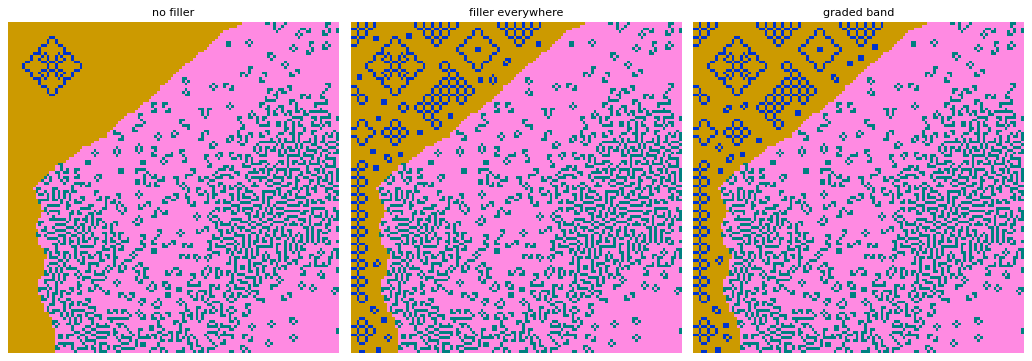

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
settings = [(None, dict(fill=None), "no filler"),
            (None, dict(fill="auto", fill_band=None), "filler everywhere"),
            (None, dict(fill="auto", fill_band=18), "graded band")]
for ax, (_, kwargs, title) in zip(axes, settings):
    art = compose(pattern, background, scheme, style="mosaic", level=4,
                  seed=1, **kwargs)
    ax.imshow(np.asarray(art)[CROP, CROP], interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()

The filler can also carry its own colour. `filled_background` numbers its
output — 1 for the main mosaic, 2 for everything packed in behind it — and
`compose` hands that straight to the renderer, so a `ColorScheme` with a
`fill_pixel` paints the two apart. A tone between the field and the tiles
turns the fringe into atmospheric recession: bright ornaments high up, hazing
out as they approach the figure. Leave `fill_pixel` unset and it falls back to
the ECA pixel colour, so nothing that ignores filler looks any different.

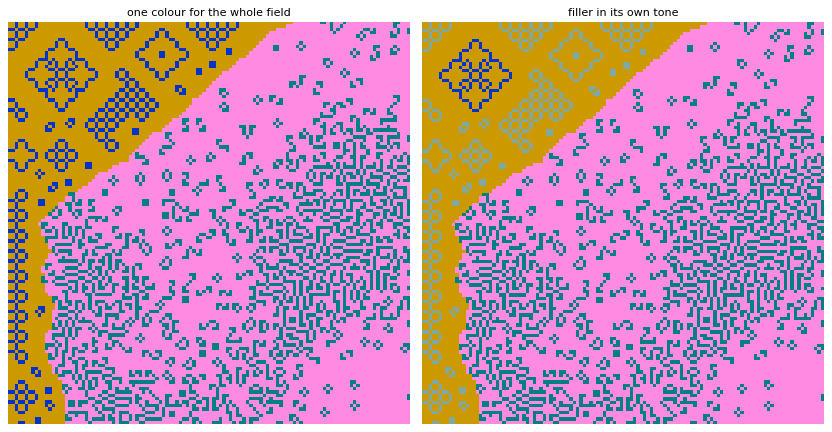

In [15]:
from dataclasses import replace

hazed = replace(scheme, fill_pixel="#7FA8A0")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.4))
for ax, palette, title in ((axes[0], scheme, "one colour for the whole field"),
                           (axes[1], hazed, "filler in its own tone")):
    art = compose(pattern, background, palette, style="mosaic", level=4,
                  fill="auto", seed=1)
    ax.imshow(np.asarray(art)[CROP, CROP], interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()

And it is still one still life. `life_safe_pattern` takes the layered field as
it is — any non-zero value counts as a live cell — and re-checks the clearance
rather than trusting it, which is the only thing standing between a caller and
a false claim.

subject 26,960 + mosaic 3,876 + filler 3,617 = 34,453 live cells
verify: {'bounded': True, 'toroidal': True}


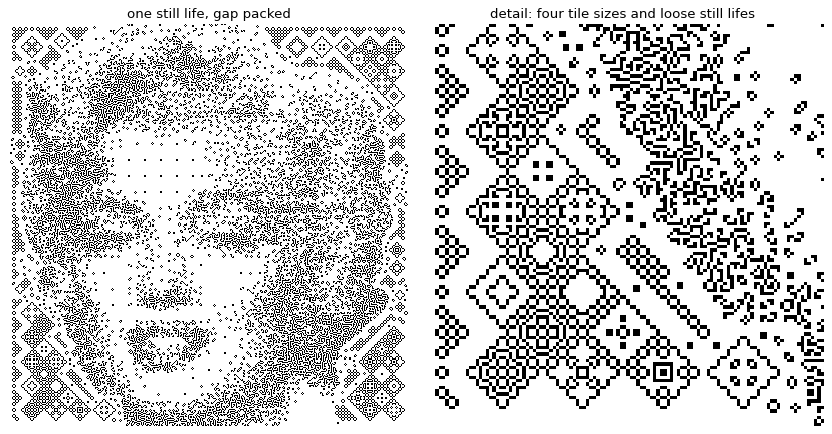

In [16]:
field = filled_background(background, level=4, seed=1)
whole_filled = life_safe_pattern(pattern, background, field=field)

print(f"subject {pattern.sum():,} + mosaic {(field == 1).sum():,} "
      f"+ filler {(field == 2).sum():,} = {whole_filled.sum():,} live cells")
print("verify:", verify_still_life(whole_filled))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 5.4))
axes[0].imshow(1 - whole_filled, cmap="gray", interpolation="nearest")
axes[0].set_title("one still life, gap packed")
axes[1].imshow(1 - whole_filled[280:400, 0:120], cmap="gray",
               interpolation="nearest")
axes[1].set_title("detail: four tile sizes and loose still lifes")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

Here is the piece, recoloured and scaled for print.

1200 x 1200 px, 49 kB -> output/images/beyond_tiles_mosaic.png


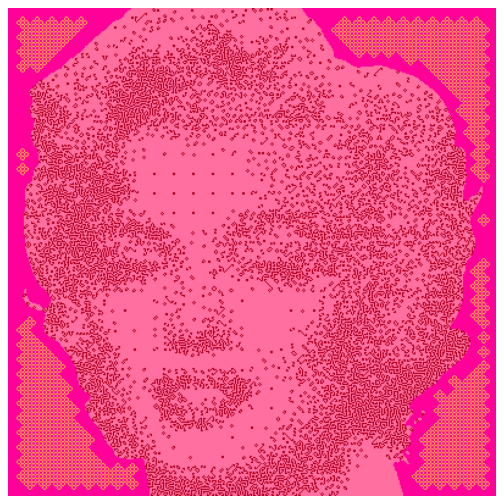

In [17]:
art = compose(pattern, background, ColorScheme.warhol(seed=11),
              style="mosaic", level=2, shape="diamond",
              density=(0.6, 1.0), seed=11, scale=3)
png = REPO / "output/images/beyond_tiles_mosaic.png"
art.save(png)
print(f"{art.size[0]} x {art.size[1]} px, {png.stat().st_size / 1024:.0f} kB "
      f"-> {png.relative_to(REPO)}")

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.imshow(np.asarray(art))
ax.axis("off")
plt.tight_layout()

## 6. Make the print

The renderer emits one pixel per cell, which is not a print. `scale` is an
integer nearest-neighbour upscale — nearest-neighbour on purpose, because
every cell should stay a hard-edged square rather than being smoothed into a
grey blur.

In [18]:
for scale in (1, 3, 6, 12):
    px = SIZE * scale
    print(f"scale {scale:2d}  ->  {px:5d} x {px:5d} px "
          f"= {px / 300 * 2.54:5.1f} cm at 300 dpi")

scale  1  ->    400 x   400 px =   3.4 cm at 300 dpi
scale  3  ->   1200 x  1200 px =  10.2 cm at 300 dpi
scale  6  ->   2400 x  2400 px =  20.3 cm at 300 dpi
scale 12  ->   4800 x  4800 px =  40.6 cm at 300 dpi


1200 x 1200 px, 49 kB -> output/images/beyond_tiles_art.png


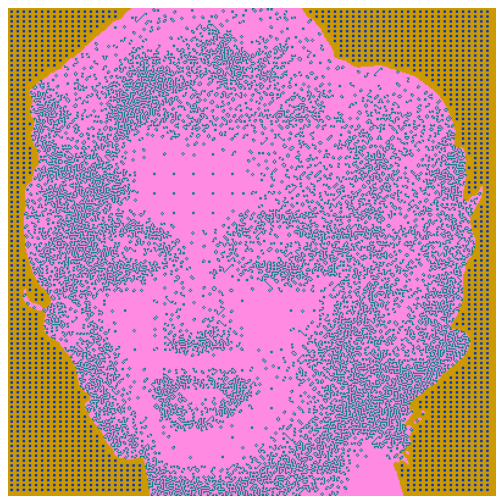

In [19]:
art = compose(pattern, background, ColorScheme.warhol(seed=7),
              style="agar", pitch=(4, 5), scale=3)
png = REPO / "output/images/beyond_tiles_art.png"
art.save(png)
print(f"{art.size[0]} x {art.size[1]} px, {png.stat().st_size / 1024:.0f} kB "
      f"-> {png.relative_to(REPO)}")

fig, ax = plt.subplots(figsize=(6.4, 6.4))
ax.imshow(np.asarray(art))
ax.axis("off")
plt.tight_layout()

At 400² a print stays small — 3.4 cm at scale 1, 34 cm only at scale 12,
where each cell is a visible 12-pixel square. That is a legitimate look, but
it is also why the flagship runs go bigger: the 1000² pipeline run and the
1416×2000 poster carry the same physical size at a fraction of the scale, so
the cells disappear into texture instead of becoming the texture.

## 7. The poster

The John Conway run is 1416×2000 cells — a real poster, solved once in
[`poster.py`](../experiments/beyond_tiles/poster.py) and then dressed however
you like. Its output lives under `experiments/beyond_tiles/results/`, which is
gitignored, so this cell runs only if you have solved it locally:

```bash
python experiments/beyond_tiles/poster.py input/images/john.png \
    --width 1416 --height 2000 --out results/john_d40
```

The mask comes back from `poster.load_rect`, with the same geometry the solve
used — no square padding, straight to the poster's aspect ratio.

(2000, 1416), 400,660 live cells, 0 in the background


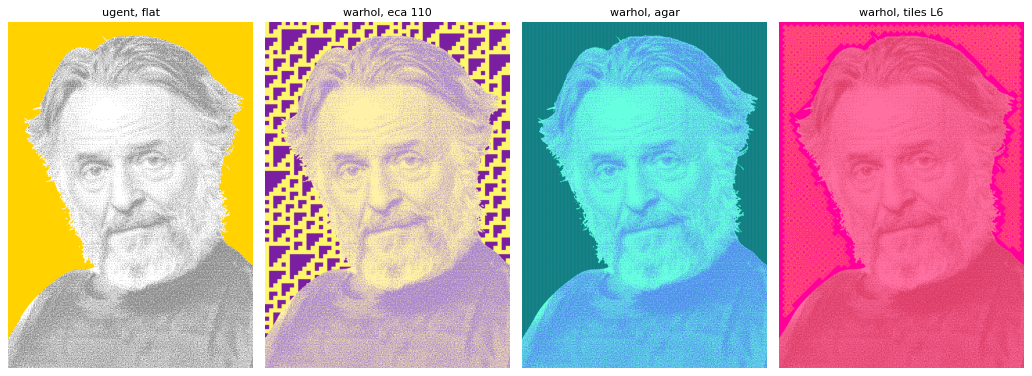

In [20]:
run = REPO / "experiments/beyond_tiles/results/john_d40"

if (run / "pattern.npy").exists():
    import json
    from beyond_tiles.poster import load_rect

    report = json.loads((run / "report.json").read_text())
    height, width = report["grid"]
    john = np.load(run / "pattern.npy")
    # Tone and contrast shape the grey targets, never the alpha mask, so the
    # geometry alone is enough to recover it.
    _, john_free = load_rect(str(REPO / report["image"]), width, height,
                             tone="raw", contrast=5.0)
    john_bg = ~john_free
    print(f"{john.shape}, {john.sum():,} live cells, "
          f"{john[john_bg].sum()} in the background")

    fig, axes = plt.subplots(1, 4, figsize=(13, 5.0))
    for ax, (title, kwargs) in zip(axes, [
        ("ugent, flat", dict(scheme=ColorScheme.ugent(), style="flat")),
        ("warhol, eca 110", dict(scheme=ColorScheme.warhol(seed=2),
                                 style="eca", rule=110, supersample=24)),
        ("warhol, agar", dict(scheme=ColorScheme.warhol(seed=5),
                              style="agar", pitch=(6, 8))),
        ("warhol, tiles L6", dict(scheme=ColorScheme.warhol(seed=11),
                                  style="mosaic", level=6, shape="diamond",
                                  density=(0.2, 0.8), tone="vignette", seed=11)),
    ]):
        ax.imshow(np.asarray(compose(john, john_bg, **kwargs)))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
else:
    print(f"no local run at {run.relative_to(REPO)} - see the command above")

## 8. Where to go next

- [`beyond_tiles.ipynb`](beyond_tiles.ipynb) is the other half: how these
  patterns get solved, why 400² is a wall, and the three escapes that get
  past it.
- `compose`, `agar_background`, `mosaic_background` and `life_safe_pattern`
  are ordinary package functions (`gol_mosaics.compose`) and work on tile
  mosaics just as well — a mosaic's `transparency_mask` is already in the
  renderer's convention, so it needs no `~`.
- The halo no longer has to be empty: `filled_background` packs it with
  smaller tiles and loose still lifes and brings the worst case on a banner
  from 73 cells to 8. What it cannot do is reach the figure — `gap + 1` is
  the still-life floor. Getting flush contact would mean re-solving a
  boundary band with CP-SAT, which is a different project.
- Aligning the lattice to the silhouette is *not* the way in: 36 phase
  offsets swept on an 800x200 banner left the mean halo between 13.7 and
  16.5 cells and the maximum never below 38. The raggedness is silhouette
  against tile size, not phase.
- Nothing here is wired into the Gradio app or a CLI. The functions are
  cheap and deterministic, so exposing `level`, `density`, `tone` and `seed`
  as controls would be a small job if the app should grow a free-form mode.